# Проект: семантический поиск товаров по текстовому запросу

**Автор:** Илья Иванов  
**Дата:** 25.09.2026

**Ваша роль.** Вы специалист по Data Science. Компания развивает онлайн-каталог товаров, и сейчас руководству кажется, что классический поиск по ключевым словам плохо справляется с реальными запросами. Пользователи пишут названия с ошибками, кириллицей, используют просторечные слова, ищут товары по назначению, а не по функциональности («удобные кроссовки для бега» вместо «мужские спортивные кроссовки с амортизацией»). Команда хочет проверить, поможет ли векторный поиск улучшить качество поисковой системы.

**Задача.** Вам нужно построить MVP системы семантического поиска, сравнить его с лексической baseline-моделью на подготовленной разметке и дать бизнесу обоснованную рекомендацию о том, где новое решение помогает, где ошибается и стоит ли его вообще внедрять.

## Данные

| Файл | Что это | Когда нужен |
|---|---|---|
| wb_products_raw_sample.parquet | Исходный каталог, ~200 тысяч строк, все категории. <br> Вам нужно самостоятельно отобрать рабочее подмножество этих данных | Недели 1–2 |
| wb_products_dedup.parquet | Пул асессоров: множество товаров, по которому делалась разметка | Неделя 2, раздел 4 |
| queries_synthetic_train.parquet | Разметка релевантности, train | Недели 2–3 |
| queries_synthetic_test.parquet | Разметка релевантности, test | **один прогон** в конце недели 3 |

Файлы с разметкой содержат четыре столбца: `query_id`, `query_text`, `item_id`, `relevance`. Шкала в `relevance` от `0` до `3`, где `0` — товар нерелевантен, а `3` — максимально релевантен. Связь с каталогом: `item_id` ↔ `imt_id`.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

SEED = 42
np.random.seed(SEED)
pd.set_option("display.max_colwidth", 150)
sns.set_theme(style="whitegrid")

DATA_DIR = Path("data")
RAW_PRODUCTS_PATH = DATA_DIR / "wb_products_raw_sample.parquet"
ASSESSED_POOL_PATH = DATA_DIR / "wb_products_dedup.parquet"
TRAIN_QUERIES_PATH = DATA_DIR / "queries_synthetic_train.parquet"
TEST_QUERIES_PATH = DATA_DIR / "queries_synthetic_test.parquet"

---

## Неделя 1 — знакомство с данными и EDA

**Цель** — понять, с какими данными работаете, чтобы принять обоснованные решения:

- выбрать категории, с которыми будете работать;
- определить, как будете очищать описания от всего лишнего;
- решить, из каких полей собирать текст товара.

**Главный критерий успеха:** любое ваше решение по данным вы можете подкрепить ссылкой на конкретные результаты анализа.

### 1. Загрузка данных

Загрузите каталог и обе разметки. Изучите их структуру: проанализируйте колонки и типы данных в них, определите, что описывает одна строка.

**Подсказка.** `imt_id` — карточка товара, `nm_id` — конкретный артикул этого товара, то есть его разновидность, отличающаяся цветом, размером или чем-то ещё. Определите, что из этого должен возвращать поиск, — от этого зависит, на каком уровне вы будете строить индекс.

In [2]:
df_raw = pd.read_parquet(RAW_PRODUCTS_PATH)
queries_train = pd.read_parquet(TRAIN_QUERIES_PATH)
queries_test = pd.read_parquet(TEST_QUERIES_PATH)

for name, df in [("каталог", df_raw), ("train", queries_train), ("test", queries_test)]:
    print(f"--- {name}: {df.shape}")
    print(df.dtypes.to_string(), end="\n\n")
df_raw.head()

--- каталог: (200000, 9)
imt_id             int64
nm_id              int64
imt_name             str
subj_name            str
subj_root_name       str
nm_colors_names      str
vendor_code          str
description          str
brand_name           str

--- train: (11453, 4)
query_id        str
query_text      str
item_id       int64
relevance     int64

--- test: (4866, 4)
query_id        str
query_text      str
item_id       int64
relevance     int64



,imt_id,nm_id,imt_name,subj_name,subj_root_name,nm_colors_names,vendor_code,description,brand_name
0,100000,118982,Сумка,Сумки,Аксессуары,бежевый,82992/beige,,Pola
1,1000000,1206857,Шапка,Шапки,Головные уборы,белый,Лаки/белый,,Ваша Шляпка
2,1000000,1206860,Шапка,Шапки,Головные уборы,черный,Лаки/черный,,Ваша Шляпка
3,10000000,13349975,Очки TRUESPIN Fold,Солнцезащитные очки,Аксессуары,черный,20S.Y.T.35.00.564/Black/Black,,True Spin
4,10000001,13349981,Очки TRUESPIN Candor,Солнцезащитные очки,Аксессуары,черный,20S.Y.T.35.00.567/Black,,True Spin


**Проверьте связность данных:** все ли `item_id` из разметки есть в каталоге, нет ли пересечения `query_id` между `train` и `test`.

In [3]:
catalog_ids = set(df_raw["imt_id"])
for name, q in [("train", queries_train), ("test", queries_test)]:
    print(
        f"{name}: пар {len(q)}, запросов {q['query_id'].nunique()}, "
        f"item_id нет в каталоге: {(~q['item_id'].isin(catalog_ids)).sum()}"
    )

for col in ("query_id", "query_text"):
    common = set(queries_train[col]) & set(queries_test[col])
    print(f"Пересечение train/test по {col}: {len(common)}")

train: пар 11453, запросов 700, item_id нет в каталоге: 0
test: пар 4866, запросов 300, item_id нет в каталоге: 0
Пересечение train/test по query_id: 0
Пересечение train/test по query_text: 0


### Вывод по загрузке данных

- **Каталог:** 200 000 строк, 9 колонок. Одна строка — артикул (`nm_id`), несколько строк могут относиться к одной карточке `imt_id`: например, шапка `imt_id=1000000` представлена белым и чёрным артикулами. Поиск должен возвращать карточки, поэтому индексируем на уровне `imt_id`, а дубликаты артикулов нужно будет устранить.
- **Разметка:** train — 11 453 пары и 700 запросов (≈16 оценённых товаров на запрос), test — 4 866 пар и 300 запросов (≈16 на запрос). Структура обеих выборок одинаковая: `query_id`, `query_text`, `item_id`, `relevance`.
- **Связность:** все `item_id` из train и test есть в каталоге (`imt_id`), подсоединять разметку можно без потерь.
- **Утечка:** пересечений между train и test нет ни по `query_id`, ни по `query_text`, то есть разбиение по запросам корректно.
- **Первое наблюдение по качеству:** в `description` уже в первых строках встречаются пустые строки, а не `NaN`. Поэтому пропуски нужно считать с учётом пустых значений.

### 2. EDA

In [4]:
n_imt, n_nm = df_raw["imt_id"].nunique(), df_raw["nm_id"].nunique()
print(f"Уникальных imt_id: {n_imt}, nm_id: {n_nm}")
print(f"Полных дубликатов строк: {df_raw.duplicated().sum()}")
print(f"Дубликатов nm_id: {df_raw['nm_id'].duplicated().sum()}")
print("Артикулов на карточку:")
df_raw.groupby("imt_id").size().describe().round(2)

Уникальных imt_id: 174427, nm_id: 199957
Полных дубликатов строк: 0
Дубликатов nm_id: 43
Артикулов на карточку:


count    174427.00
mean          1.15
std           0.88
min           1.00
25%           1.00
50%           1.00
75%           1.00
max          30.00
dtype: float64

**Вывод: структура каталога**

- 200 000 строк описывают 174 427 карточек (`imt_id`) и 199 957 артикулов (`nm_id`).
- Карточки в основном «одноартикульные»: медиана — 1 артикул, среднее — 1.15, но встречаются карточки с числом артикулов до 30. Если индексировать артикулы, такие товары будут многократно конкурировать сами с собой в выдаче. Поэтому индексируем на уровне `imt_id` и оставляем одну строку на карточку.
- Полных дубликатов строк нет. 43 `nm_id` повторяются с различиями в полях. Это 0.02% данных, и вопрос снимается дедупликацией по `imt_id`.

In [5]:
text_cols = [
    "imt_name",
    "description",
    "nm_colors_names",
    "brand_name",
    "subj_name",
    "subj_root_name",
]
missing = pd.DataFrame(
    {
        "nan": df_raw[text_cols].isna().mean(),
        "empty": df_raw[text_cols].apply(lambda s: s.str.strip().eq("").mean()),
    }
)
missing["total"] = missing.sum(axis=1)
(missing * 100).round(2).sort_values("total", ascending=False)

,nan,empty,total
description,0.0,28.75,28.75
nm_colors_names,0.0,17.11,17.11
imt_name,0.0,0.35,0.35
brand_name,0.0,0.10,0.10
subj_name,0.0,0.00,0.00
subj_root_name,0.0,0.00,0.00


**Вывод: пропуски**

- Явных `NaN` нет ни в одной колонке: все пропуски закодированы пустыми строками, поэтому `isna()` показал бы обманчиво чистую картину.
- `description` пуст у **28.75%** строк. Это системное свойство данных, а не случайность. Такие товары не удаляем: их текст для эмбеддинга соберём из названия и категории, а флаг `has_description` понадобится позже для проверки, не проседает ли на них качество поиска.
- `nm_colors_names` пуст у 17.11% строк. Цвет — вспомогательный атрибут, проверим, нужен ли он в тексте.
- `imt_name` пуст у 0.35%, `brand_name` — у 0.10%. Категории заполнены полностью.
- При дедупликации будем оставлять строку с самым длинным описанием, поэтому на уровне карточек доля товаров без описания может снизиться. Пересчитаем её на подготовленном каталоге.

In [6]:
cards = df_raw.drop_duplicates("imt_id").set_index("imt_id")
pool_ids = pd.read_parquet(ASSESSED_POOL_PATH, columns=["imt_id"])["imt_id"]
labeled = pd.concat([queries_train, queries_test])
relevant_ids = labeled.loc[labeled["relevance"] >= 2, "item_id"]


def root_share(ids=None):
    """Доля карточек по корневым категориям (в %)."""
    s = cards["subj_root_name"]
    s = s if ids is None else s[s.index.isin(ids)]
    return s.value_counts(normalize=True) * 100


roots = (
    pd.DataFrame(
        {
            "catalog": root_share(),
            "pool": root_share(pool_ids),
            "relevant": root_share(relevant_ids),
        }
    )
    .fillna(0)
    .sort_values("relevant", ascending=False)
)
roots["relevant_cum"] = roots["relevant"].cumsum()
print(f"Корневых категорий: {len(roots)}")
roots.head(15).round(2)

Корневых категорий: 65


,catalog,pool,relevant,relevant_cum
subj_root_name,,,,
Одежда,21.19,79.44,73.35,73.35
Обувь,6.61,20.56,26.65,100.00
,0.00,0.00,0.00,100.00
Автомобильные товары,2.21,0.00,0.00,100.00
Автоэлектроника,0.05,0.00,0.00,100.00
Аксессуары для малышей,0.07,0.00,0.00,100.00
Аксессуары для обуви,0.15,0.00,0.00,100.00
Аксессуары,7.58,0.00,0.00,100.00
Аксессуары для волос,0.99,0.00,0.00,100.00


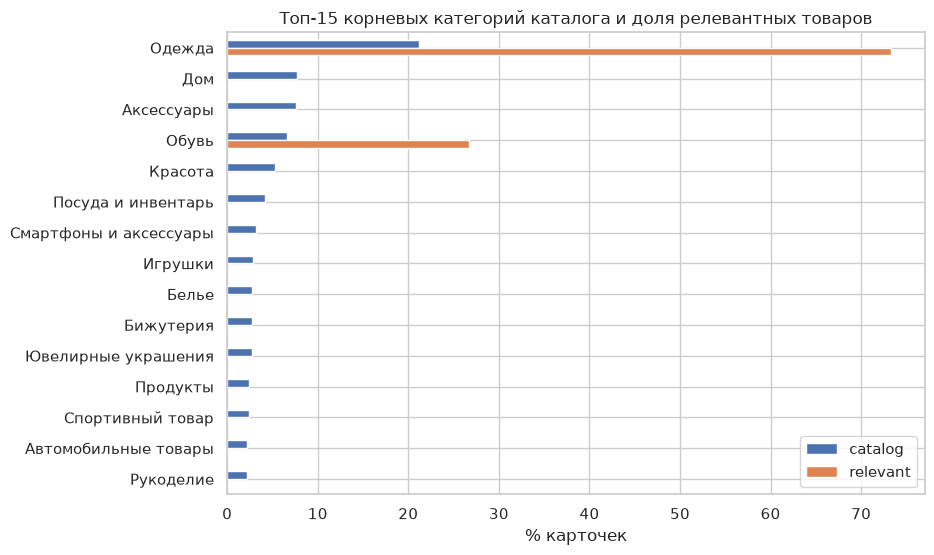

In [7]:
top = roots.sort_values("catalog", ascending=False).head(15)
ax = top[["catalog", "relevant"]].plot.barh(figsize=(9, 6))
ax.invert_yaxis()
ax.set(
    xlabel="% карточек",
    ylabel="",
    title="Топ-15 корневых категорий каталога и доля релевантных товаров",
)
plt.show()

In [8]:
subj = cards["subj_name"].value_counts()
print(f"Уникальных subj_name: {len(subj)}, с 1–2 карточками: {(subj <= 2).sum()}")
print("\nСамые частые:", subj.head(10).to_dict())
print("\nСамые редкие:", subj.tail(10).to_dict())

Уникальных subj_name: 3234, с 1–2 карточками: 820

Самые частые: {'Платья': 6113, 'Футболки': 4524, 'Сумки': 4050, 'Брюки': 2858, 'Постельное белье': 2342, 'Чехлы для телефонов': 2189, 'Автомобильные ароматизаторы': 2157, 'Блузки': 2076, 'Костюмы': 2025, 'Туфли': 2013}

Самые редкие: {'Вилки поварские': 1, 'Сумки для сбора урожая': 1, 'Межпальцевые перегородки': 1, 'Кронштейны для аудиотехники': 1, 'DVD-плееры': 1, 'Ведерки детские': 1, 'Карнавальные парики': 1, 'Средства профилактики': 1, 'Гладильные системы': 1, 'Стиральные машины активаторного типа': 1}


**Вывод: категории**

- В каталоге 65 корневых категорий. Самые крупные — «Одежда» (21.2% карточек), «Аксессуары» (7.6%) и «Обувь» (6.6%). Встречается и пустое значение `subj_root_name` (доли процента).
- **Весь пул асессоров и все релевантные товары разметки (relevance ≥ 2) лежат только в двух корнях: «Одежда» (73% релевантных) и «Обувь» (27%).** Остальные 63 корня в разметке не представлены.
- **Решение: MVP строим на категориях «Одежда» и «Обувь».** Их товары покрывают разметку полностью, у них понятные атрибуты (назначение, сезон, пол, материал), а ошибки поиска в таком домене легко интерпретировать. Если бы в индекс попали остальные категории, выросли бы объём вычислений и шум в выдаче, а метрики не получили бы ни одного размеченного товара.
- Предметных категорий `subj_name` — 3 234, из них 820 содержат 1–2 карточки. Хвост в основном состоит из категорий вне выбранного домена (поварские вилки, DVD-плееры). В редких категориях внутри домена качество поиска будет менее стабильным, это учтём при анализе ошибок.
- Самые частые предметные категории внутри домена — «Платья», «Футболки», «Брюки», «Блузки», «Костюмы», «Туфли».

In [9]:
DOMAIN_ROOTS = ["Одежда", "Обувь"]

df_dom = df_raw[df_raw["subj_root_name"].isin(DOMAIN_ROOTS)]
cards_dom = (
    df_dom.assign(desc_len=df_dom["description"].str.len())
    .sort_values("desc_len", ascending=False)
    .drop_duplicates("imt_id")
)
has_desc = cards_dom["description"].str.strip().ne("")

print(f"Строк в домене: {len(df_dom)}, карточек: {len(cards_dom)}")
print(f"Карточек без описания: {(~has_desc).mean():.1%}")
print(cards_dom["subj_root_name"].value_counts().to_string())

subj_dom = cards_dom["subj_name"].value_counts()
print(
    f"\nsubj_name в домене: {len(subj_dom)}, с 1–2 карточками: {(subj_dom <= 2).sum()}"
)
subj_dom.head(15)

Строк в домене: 56503, карточек: 48489
Карточек без описания: 62.7%
subj_root_name
Одежда    36965
Обувь     11524

subj_name в домене: 104, с 1–2 карточками: 5


subj_name
Платья       6113
Футболки     4524
Брюки        2858
Блузки       2076
Костюмы      2025
Туфли        2013
Джинсы       1661
Кроссовки    1476
Юбки         1471
Рубашки      1444
Ботинки      1349
Джемперы     1233
Куртки       1206
Шорты        1077
Босоножки    1049
Name: count, dtype: int64

In [10]:
desc = cards_dom["description"].where(has_desc)
lengths = pd.DataFrame(
    {
        "name_chars": cards_dom["imt_name"].str.len(),
        "name_words": cards_dom["imt_name"].str.split().str.len(),
        "desc_chars": desc.str.len(),
        "desc_words": desc.str.split().str.len(),
    }
)
display(lengths.describe(percentiles=[0.5, 0.9, 0.99]).round(1))
for n in (200, 350):
    print(
        f"Описаний длиннее {n} слов: "
        f"{(lengths['desc_words'] > n).sum() / has_desc.sum():.1%}"
    )

,name_chars,name_words,desc_chars,desc_words
count,48489.0,48489.0,18087.0,18087.0
mean,13.9,1.9,414.6,56.8
std,15.2,1.9,439.5,58.9
min,0.0,0.0,1.0,1.0
50%,8.0,1.0,283.0,39.0
90%,33.0,4.0,890.0,122.0
99%,82.1,10.0,2157.8,292.0
max,100.0,19.0,5000.0,704.0


Описаний длиннее 200 слов: 3.1%
Описаний длиннее 350 слов: 0.4%


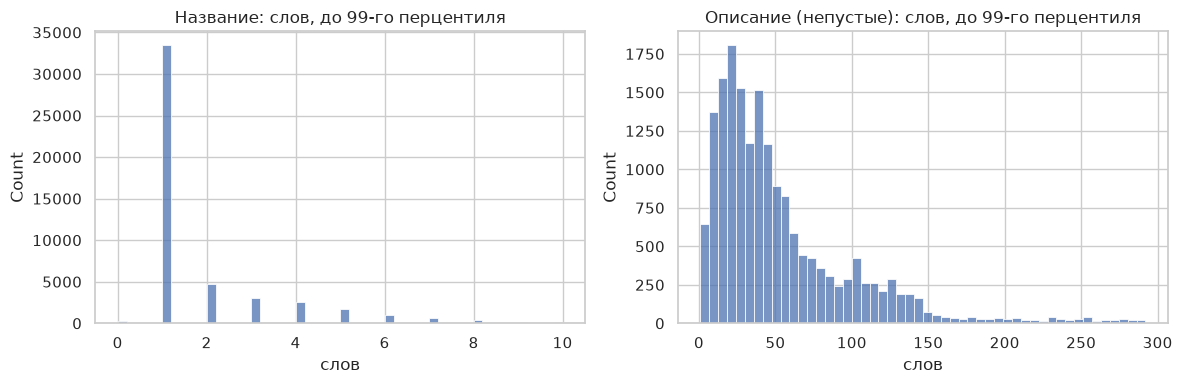

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col, title in zip(
    axes, ["name_words", "desc_words"], ["Название", "Описание (непустые)"]
):
    s = lengths[col].dropna()
    sns.histplot(s[s <= s.quantile(0.99)], bins=50, ax=ax)
    ax.set(title=f"{title}: слов, до 99-го перцентиля", xlabel="слов")
plt.tight_layout()
plt.show()

In [12]:
cards_dom.loc[
    lengths["desc_chars"].nlargest(3).index, ["imt_name", "subj_name", "description"]
]

,imt_name,subj_name,description
41407,"Блузка женская ""Tracy"", большие размеры",Блузки,Милые наши покупательницы! Мы от души благодарим Вас за долгие годы верности нашему бренду! И с удовольствием дарим вам более 60% ассортимента по ...
41402,"Блузка женская ""Nancy"",большие размеры",Блузки,Милые наши покупательницы! Мы от души благодарим Вас за долгие годы верности нашему бренду! И с удовольствием дарим вам более 60% ассортимента по ...
120006,"Футболка женская ""Gloria"", большие размеры",Футболки,"Базовая модель для вашего гардероба. Отличный всесезонный вариант. Весной и летом станет основным элементом вашего образа, а осенью-зимой оставит ..."


**Вывод: домен и длина текстов**

- После фильтрации по «Одежде» и «Обуви» остаётся 56 503 строки и **48 489 карточек** (36 965 — одежда, 11 524 — обувь). Предметных категорий в домене 104, только 5 из них содержат 1–2 карточки, так что хвост редких категорий почти ушёл вместе с другими корнями. Самые частые категории — «Платья», «Футболки», «Брюки», «Блузки», «Костюмы», «Туфли».
- **Описания нет у 62.7% карточек домена** (по всему каталогу — 29%), даже с учётом того, что для каждой карточки выбрана строка с самым длинным описанием. Для большинства товаров текст для поиска будет собираться только из названия, категории и атрибутов.
- **Названия предельно короткие:** медиана — 1 слово и 8 символов, 90-й перцентиль — 4 слова, максимум — 100 символов. У многих карточек `imt_name` фактически повторяет категорию («Платье»). Встречаются и пустые названия (min = 0).
- **Описания** (по 18 087 непустым): медиана — 39 слов / 283 символа, 90-й перцентиль — 122 слова, 99-й — 292 слова. Длиннее 200 слов — 3.1%, длиннее 350 — 0.4%. Максимум ровно 5 000 символов, похоже на обрезку при выгрузке. Лимит модели в 512 токенов потребует обрезки лишь у небольшой доли описаний. Точную долю посчитаем токенизатором выбранной модели.
- **Выбросы — это рекламные шаблоны, а не описание товара:** самые длинные тексты начинаются с обращения бренда к покупательницам и повторяются у разных моделей одного бренда. Такие тексты размывают эмбеддинг, их нужно выявить при очистке.
- **Следствие для `product_text`:** описание обязательно ставить **после** названия и категории, чтобы смысловое ядро не утонуло в длинных текстах. При коротких названиях атрибуты (бренд, цвет) могут оказаться главным источником различий между товарами.

In [13]:
for r in cards_dom[has_desc].sample(20, random_state=SEED).itertuples():
    print(
        f"[{r.subj_name}] {r.imt_name!r} | бренд: {r.brand_name} | "
        f"цвет: {r.nm_colors_names} | артикул: {r.vendor_code}"
    )
    print(f"    {r.description[:300]}\n")

print("Без описания:")
print(
    cards_dom.loc[~has_desc, ["imt_name", "subj_name", "brand_name", "nm_colors_names"]]
    .sample(10, random_state=SEED)
    .to_string()
)

[Ветровки] 'Ветровка из хлопка' | бренд: L.A.G. | цвет: бежевый | артикул: galina2У-16Ветровках/б1803светлбеж
    Комфортная и стильная ветровка из хлопка незаменима для прохладных дней! Удлиненный крой, кулиски на талии для большего облегания, застежка молния закрыта планкой на кнопках. Рукав можно подвернуть при помощи патов до  длины 3/4. Длина 80 см. Рукав 63 см. Замеры  для 52 размера.

[Босоножки] 'Босоножки женские Thorpeness' | бренд: BALDI | цвет: черный | артикул: Thorpenessblack
    Удобные женские босоножки от Baldi

[Шорты] 'Шорты' | бренд: TITOY | цвет: темно-синий | артикул: П-0024
    Юбка - шорты ( шорты ) школьные для девочек из поликоттона ( хлопок смесовый ) темно - синего цвета. Посадка высокая, свободная, талия фиксируется резинкой и поясом, глубина посадки варьируется лямками ( сзади пришивные перекрещивающиеся, впереди застегиваются на пуговицы, пуговицы при необходимости

[Кеды] 'Кеды кожаные' | бренд: MAGMA | цвет: черный | артикул: GSA410/черный
    Кеды мужс

In [14]:
PATTERNS = {
    "html": r"<[^>]+>|&[a-z]+;|&#\d+;",
    "url": r"https?://|www\.",
    "спецсимволы": r'[^\w\s.,:;!?()\-–—«»"\'/%+№*°]',
    "повторы пунктуации": r"[!?]{3,}|\.{4,}|[*_=~-]{3,}",
    "коды с цифрами": r"\b(?=\w*\d)(?=\w*[^\W\d])\w{4,}\b",
}
texts = {
    "imt_name": cards_dom["imt_name"].astype(object),
    "description": desc.dropna().astype(object),
}
display(
    pd.DataFrame(
        {
            col: {name: s.str.contains(p).mean() * 100 for name, p in PATTERNS.items()}
            for col, s in texts.items()
        }
    )
    .round(2)
    .rename_axis("% текстов")
)

print(
    "Частые спецсимволы:",
    texts["description"]
    .str.findall(PATTERNS["спецсимволы"])
    .explode()
    .value_counts()
    .head(15)
    .to_dict(),
)

vendor = cards_dom["vendor_code"].str.lower().str.strip()
name_low = cards_dom["imt_name"].str.lower()
print(
    f"Артикул поставщика в названии: "
    f"{np.mean([bool(v) and v in n for v, n in zip(vendor, name_low)]):.1%}"
)

print(
    f"Карточек с неуникальным описанием: "
    f"{desc.dropna().duplicated(keep=False).mean():.1%}"
)
print("\nСамые частые названия:")
cards_dom["imt_name"].value_counts().head(10)

,imt_name,description
% текстов,,
html,0.00,0.03
url,0.00,0.00
спецсимволы,0.10,0.49
повторы пунктуации,0.01,0.52
коды с цифрами,0.41,3.59


Частые спецсимволы: {'|': 88, '•': 43, '&': 42, '―': 11, '”': 9, '=': 9, '“': 8, '#': 5, '@': 5, '<': 4, '>': 4, '\\': 4, '·': 4, '`': 3, '’': 3}
Артикул поставщика в названии: 0.1%
Карточек с неуникальным описанием: 35.5%

Самые частые названия:


imt_name
Платье       4212
Футболка     2524
Брюки        1898
Туфли        1422
Ботинки      1124
Блузка       1052
Джинсы       1032
Рубашка      1021
Юбка          981
Кроссовки     887
Name: count, dtype: int64

In [15]:
brands = cards_dom.loc[cards_dom["brand_name"].str.strip().ne(""), "brand_name"]
print(
    f"Брендов: {brands.nunique()}, "
    f"медиана карточек на бренд: {brands.value_counts().median():.0f}"
)
print(
    f"Бренд в названии: {np.mean([b.lower() in n for b, n in zip(cards_dom['brand_name'], name_low) if b]):.1%}"
)

has_color = cards_dom["nm_colors_names"].str.strip().ne("")
stem = (
    cards_dom.loc[has_color, "nm_colors_names"]
    .str.split(",")
    .str[0]
    .str.strip()
    .str.lower()
    .str[:-2]
)
print(
    f"\nКарточек с цветом: {has_color.mean():.1%}, уникальных цветов: {stem.nunique()}"
)
for col in ("imt_name", "description"):
    text = cards_dom.loc[has_color, col].str.lower()
    print(f"Цвет упомянут в {col}: {np.mean([s in t for s, t in zip(stem, text)]):.1%}")

colors_per_card = df_dom.groupby("imt_id")["nm_colors_names"].nunique()
print(f"Карточек с разными цветами у артикулов: {(colors_per_card > 1).mean():.1%}")

Брендов: 3915, медиана карточек на бренд: 4
Бренд в названии: 1.2%

Карточек с цветом: 98.2%, уникальных цветов: 237
Цвет упомянут в imt_name: 1.5%
Цвет упомянут в description: 4.2%
Карточек с разными цветами у артикулов: 8.7%


**Вывод: качество текста, бренд и цвет**

- **Текст в целом чистый.** HTML встречается в 0.03% описаний, URL нет, спецсимволы (`|`, `•`, `&`, типографские кавычки и тире) — в 0.5%, повторы пунктуации — в 0.5%. Коды с цифрами есть в 3.6% описаний и 0.4% названий, в основном это размеры, составы и модели («52 размера», «95% хлопок»), а не мусор. Артикул поставщика в названии почти не встречается (0.1%).
- **Что учесть в функции очистки:** удалить HTML-теги и сущности, заменить `|`, `•` и прочие спецсимволы пробелом, привести типографские кавычки к единому виду, свернуть повторы пунктуации и пробелов. Пробелы вокруг дефисов («темно - синего») не трогаем: одним правилом их не отличить от тире в предложении, а токенизаторам они не мешают. Регистр не меняем: TF-IDF понижает его сам. Очистка одна и та же для товаров и запросов.
- **`vendor_code` в текст не берём:** это служебные строки вроде `galina2У-16Ветровках/б1803светлбеж`, смысла они не несут, а словарь TF-IDF засоряют.
- **Шаблонные описания:** у 35.5% карточек с описанием оно не уникально. Бренды копируют один текст («Милые наши покупательницы!…») на разные модели. Такое описание не различает товары, поэтому его ставим в конец `product_text`.
- **Название часто совпадает с категорией:** самые частые названия — «Платье» (4 212), «Футболка» (2 524), «Брюки» (1 898). У этих карточек `imt_name` и `subj_name` несут одну и ту же информацию. При этом `subj_name` иногда шире названия («Плащ» лежит в «Куртках», юбка-шорты — в «Шортах»), поэтому категорию в тексте оставляем.
- **Бренд:** 3 915 брендов, медиана — 4 карточки на бренд, в названии бренд упомянут у 1.2% карточек. Бренд — точный идентификатор, а не смысловой признак. Включать ли его в текст эмбеддинга, решим по тому, упоминают ли бренды в запросах.
- **Цвет:** заполнен у 98.2% карточек, 237 уникальных значений, в названии упомянут только у 1.5%, в описании — у 4.2%. **Цвет не дублирует название и включается в `product_text`.** У 8.7% карточек артикулы разных цветов, поэтому при дедупликации цвета объединяем по всем артикулам карточки, а не берём из одной строки.

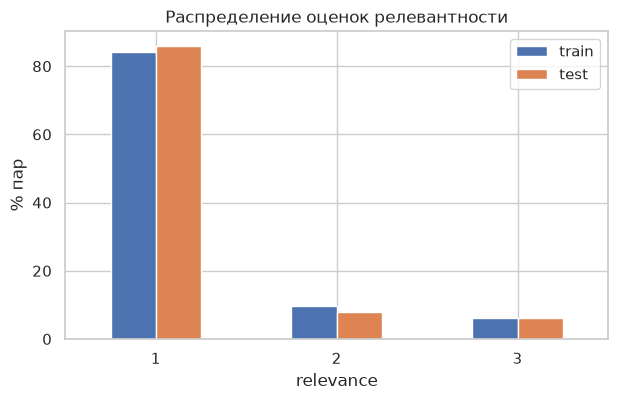

,n_items,n_rel,max_rel
count,700.00,700.00,700.0
mean,16.36,2.57,3.0
std,5.42,2.47,0.0
min,1.00,1.00,3.0
25%,14.00,1.00,3.0
50%,16.00,1.00,3.0
75%,19.00,3.00,3.0
max,31.00,17.00,3.0


Запросов без товаров с relevance ≥ 2: 0


In [16]:
rel_dist = pd.DataFrame(
    {
        name: q["relevance"].value_counts(normalize=True).sort_index() * 100
        for name, q in [("train", queries_train), ("test", queries_test)]
    }
)
ax = rel_dist.plot.bar(rot=0, figsize=(7, 4))
ax.set(xlabel="relevance", ylabel="% пар", title="Распределение оценок релевантности")
plt.show()

q_stats = queries_train.groupby("query_id")["relevance"].agg(
    n_items="size", n_rel=lambda r: (r >= 2).sum(), max_rel="max"
)
display(q_stats.describe().round(2))
print(f"Запросов без товаров с relevance ≥ 2: {(q_stats['n_rel'] == 0).sum()}")

In [17]:
q_text = queries_train.drop_duplicates("query_id")["query_text"]
print(
    "Длина запроса в словах:",
    q_text.str.split().str.len().describe().round(1).to_dict(),
)
print(*q_text.sample(15, random_state=SEED), sep="\n")

q_low = q_text.str.lower().astype(object)
brand_set = {b.lower() for b in brands.unique() if len(b) >= 4}
color_set = {s for s in stem.unique() if len(s) >= 3}
for label, vocab in [("бренд", brand_set), ("цвет", color_set)]:
    print(
        f"Запросов с упоминанием {label}а: "
        f"{q_low.map(lambda q: any(w in q for w in vocab)).mean():.1%}"
    )

top_pairs = queries_train[queries_train["relevance"] == 3].merge(
    cards_dom[["imt_id", "imt_name", "description"]],
    left_on="item_id",
    right_on="imt_id",
)
literal = [
    q.lower() in f"{n} {d}".lower()
    for q, n, d in zip(
        top_pairs["query_text"], top_pairs["imt_name"], top_pairs["description"]
    )
]
print(f"Запрос дословно входит в текст карточки (rel = 3): {np.mean(literal):.1%}")

Длина запроса в словах: {'count': 700.0, 'mean': 2.7, 'std': 0.9, 'min': 2.0, '25%': 2.0, '50%': 2.0, '75%': 3.0, 'max': 7.0}
топы cop copine
худи mego as
бриджи зуавы
кожаные мокасины
кожаные сабо с открытым мысом
классические джинсовые джинсы
шубы натуральные на пуговицах
тапочки asd
тапочки t taccardi
кигуруми londe
джеггинсы утягивающие
дышащий дутики
мужские резиновые сапоги
прямые жакеты
пальто crockid
Запросов с упоминанием бренда: 35.9%
Запросов с упоминанием цвета: 17.0%
Запрос дословно входит в текст карточки (rel = 3): 6.6%


**Вывод: разметка**

- **Шкала фактически 1–3, оценки 0 нет.** Распределение сильно несбалансировано: оценка 1 — 84% пар в train и 86% в test, 2 — около 10% и 8%, 3 — около 6% в обеих выборках. Распределения train и test совпадают. Оценка 1 соответствует кандидатам, которые асессор счёл неподходящими или слабо подходящими. **Порог бинаризации — `RELEVANCE_THRESHOLD = 2`**: релевантными считаем товары с оценкой 2 и 3. При пороге 1 релевантными оказались бы все размеченные товары.
- **Товаров на запрос:** в среднем 16.4 (от 1 до 31). Релевантных (≥ 2) — медиана 1, среднее 2.6, максимум 17. У каждого запроса есть хотя бы один товар с оценкой 3, запросов без релевантных товаров нет.
- **Потолок метрик:** при одном релевантном товаре Precision@5 не может превысить 0.2, а Precision@10 — 0.1 даже у идеальной системы. Поэтому ключевыми считаем **NDCG@10** (использует всю шкалу 1–3), **Recall@10** и **MRR**, а Precision@K интерпретируем с учётом этого ограничения.
- **Запросы короткие и пользовательские:** 2–7 слов, медиана 2. Типичная структура — «категория + уточнение»: назначение или фасон («мужские резиновые сапоги», «кожаные сабо с открытым мысом»), либо бренд, часто латиницей («тапочки t taccardi», «пальто crockid»). Встречаются разговорные и неточные формулировки («дышащий дутики», «классические джинсовые джинсы»).
- **Бренд упомянут в ~36% запросов, цвет — в ~17%.** Оценка приблизительная, поиск идёт по подстроке и может давать ложные совпадения. Для брендовых запросов важно точное совпадение, поэтому **бренд включаем в `product_text`**, и он же будет сильной стороной лексического поиска. Цвет тоже включаем.
- **Задача действительно query-to-item, а не item-to-item:** дословно запрос входит в текст карточки лишь в 6.6% пар с оценкой 3. Лексический поиск не получает тривиального преимущества, но на брендовых запросах, скорее всего, будет сильнее семантического. Это кандидат на гибридный поиск.

### Итоговые решения по данным

1. **Уровень индексации — карточка `imt_id`.** Для каждой карточки оставляем строку с самым длинным описанием, а цвета объединяем по всем её артикулам.
2. **Домен — корневые категории «Одежда» и «Обувь»:** 48 489 карточек, 100% пула асессоров и релевантных товаров разметки.
3. **Пропуски:** карточки без описания (62.7%) не удаляем, текст для них собираем из названия, категории и атрибутов, а флагом `has_description` отмечаем для анализа ошибок. Удаляем только карточки без названия и без описания одновременно.
4. **Очистка:** HTML, спецсимволы, типографика, повторы пунктуации и пробелов. `vendor_code` не используем.
5. **Шаблон `product_text` (базовый):** `название. категория. бренд. цвета. описание`. Описание стоит в конце, чтобы длинные и шаблонные тексты не вытесняли смысловое ядро при обрезке по лимиту модели. Варианты для экспериментов — без описания и без бренда.
6. **Оценка:** порог `relevance ≥ 2`; основные метрики — NDCG@10, Recall@10, MRR, дополнительные — Precision@5, HitRate@K; K ∈ {1, 3, 5, 10}.

---

## Неделя 2 — базовый пайплайн и оценка качества

**Цель:** оперевшись на результаты EDA, создать работающий поиск и получить первые метрики качества.

Прежде чем реализовывать семантический поиск, основанный на эмбеддингах, нужно проверить, как справляется более простая модель, опирающаяся на TF-IDF. Простая модель нужна как baseline, без этой точки отсчёта результат невозможно интерпретировать.


### 1. Подготовка данных


Реализуйте решения недели 1:

1. Отфильтруйте выбранные категории.
2. Дедуплицируйте строки по `imt_id`. Сформулируйте правило, по которому будете определять, какую строку оставить. К примеру, можете оставить строку с самым информативным описанием. Ответ обоснуйте.
3. Отбросьте карточки, у которых пусты одновременно и `imt_name`, и `description`.
4. Напишите функцию очистки текста.
5. Соберите единый текст карточек в отдельной колонке `product_text`.

In [18]:
import html
import re

SPECIAL_RE = re.compile(r'[^\w\s.,:;!?()\-–—«»"\'/%+№*°]')
TEMPLATE = ["imt_name", "subj_name", "brand_name", "colors", "description"]


def clean_text(text: str) -> str:
    """Очищает текст товара или запроса от разметки и мусорных символов."""
    text = html.unescape(text)
    text = re.sub(r"<[^>]+>", " ", text)
    text = re.sub(r"[“”„]", '"', text)
    text = SPECIAL_RE.sub(" ", text)
    text = re.sub(r"([!?.,*_=~-])\1+", r"\1", text)
    return re.sub(r"\s+", " ", text).strip()


def build_product_text(df: pd.DataFrame, fields: list[str]) -> pd.Series:
    """Склеивает непустые поля карточки через явный разделитель без повторов."""
    return df[fields].apply(
        lambda row: ". ".join(dict.fromkeys(filter(None, row))), axis=1
    )

In [19]:
df_dom = df_raw[df_raw["subj_root_name"].isin(DOMAIN_ROOTS)]

# Все цвета карточки по её артикулам, без повторов и с сохранением порядка
colors = (
    df_dom.assign(color=df_dom["nm_colors_names"].str.split(","))
    .explode("color")
    .assign(color=lambda d: d["color"].str.strip().str.lower())
    .query('color != ""')
    .groupby("imt_id")["color"]
    .agg(lambda s: ", ".join(dict.fromkeys(s)))
    .rename("colors")
)

# Одна строка на карточку: с самым длинным описанием (nm_id - для детерминизма)
catalog = (
    df_dom.assign(desc_len=df_dom["description"].str.len())
    .sort_values(["desc_len", "nm_id"], ascending=[False, True])
    .drop_duplicates("imt_id")
    .join(colors, on="imt_id")[["imt_id", "subj_root_name"] + TEMPLATE]
)

catalog[TEMPLATE] = catalog[TEMPLATE].apply(
    lambda s: s.fillna("").astype(object).map(clean_text)
)

empty = catalog["imt_name"].eq("") & catalog["description"].eq("")
catalog = catalog[~empty].reset_index(drop=True)
catalog["has_description"] = catalog["description"].ne("")
catalog["product_text"] = build_product_text(catalog, TEMPLATE)

print(f"Строк в домене: {len(df_dom)}, карточек: {catalog.shape[0] + empty.sum()}")
print(f"Отсеяно без названия и описания: {empty.sum()}")
print(
    f"Итоговый каталог: {len(catalog)}, "
    f"с описанием: {catalog['has_description'].mean():.1%}"
)
catalog.to_parquet(DATA_DIR / "catalog.parquet", index=False)

Строк в домене: 56503, карточек: 48489
Отсеяно без названия и описания: 113
Итоговый каталог: 48376, с описанием: 37.4%


In [20]:
for text in catalog["product_text"].sample(8, random_state=SEED):
    print(text[:250], end="\n\n")

Джинсы женские 04J. Джинсы. Grunge John Orchestra. Explosion. синий

Брюки женские. Брюки. Zolla. черный. Брюки-джоггеры на кулиске гарантируют максимальный комфорт. Они идеально впишутся не только в повседневный образ, но и подойдут для офиса с нестрогим дресс-кодом. Модель дополнена боковыми карманами и манжетами по

Джемпер. Джемперы. Converse. серый

Футболка "RAY". Футболки. Ray Style. черный

Брюки спортивные женские/. Брюки. Moliza. морковный. На фотографии параметры модели: рост 160 см, размер 42/XS. Длина по внутреннему шву 71 см. Внешняя длина 99 см.

Кроссовки. Adal. черный

Свитшот. Свитшоты. Mark Formelle. бордовый

Босоножки. BESMODA. розовый



**Вывод: подготовка данных**

- Фильтр по «Одежде» и «Обуви»: 56 503 строки → дедупликация по `imt_id` → 48 489 карточек. Для каждой карточки оставлена строка с самым длинным описанием (при равной длине — с меньшим `nm_id`, для воспроизводимости). Цвета объединены по всем артикулам карточки.
- Отсеяно **113 карточек (0.2%)** без названия и описания одновременно, это не проблема качества каталога. **Итоговый каталог — 48 376 карточек**, описание есть у 37.4%. Карточки без описания оставлены, у них есть флаг `has_description`.
- Очистка: HTML-сущности и теги, типографские кавычки, спецсимволы, повторы пунктуации и пробелов. Регистр сохранён: TF-IDF понижает его сам, а трансформерам он не мешает.
- `product_text = название. категория. бренд. цвета. описание`. Пустые поля и повторяющиеся значения пропускаются (например, когда название совпадает с категорией). Ручная проверка на 8 примерах артефактов не выявила.
- Каталог сохранён в `data/catalog.parquet` для повторного использования и Streamlit-приложения.

### Каталог для поиска и оценки

1. Посчитайте метрику при поиске по всему отфильтрованному каталогу. Например, вычислите NDCG@10 лексическим поиском на 100 запросах.
2. Выведите топ-10 для одного запроса и отметьте, какие товары есть в разметке, а каких нет. Выясните, в чём проблема.
3. Ограничьте каталог оценки пулом асессоров: возьмите из `wb_products_dedup.parquet` только список `imt_id` и оставьте в своём подготовленном каталоге пересечение с ним. Тексты и все признаки — ваши, из шага 1.
4. Пересчитайте метрику и сравните результаты.
5. Посмотрите на распределение `relevance` и число оценённых товаров на запрос. Проверьте, у всех ли запросов есть товары с `relevance` ≥ 2.

In [21]:
pool_ids = pd.read_parquet(ASSESSED_POOL_PATH, columns=["imt_id"])["imt_id"]
catalog_eval = catalog[catalog["imt_id"].isin(pool_ids)].reset_index(drop=True)
print(
    f"Пул асессоров: {pool_ids.nunique()}, "
    f"из него в каталоге: {len(catalog_eval)}, "
    f"с описанием: {catalog_eval['has_description'].mean():.1%}"
)

# Не потеряли ли размеченные товары при подготовке (порог >= 2 - см. раздел 3)
for name, q in [("train", queries_train), ("test", queries_test)]:
    in_eval = q["item_id"].isin(catalog_eval["imt_id"])
    has_rel = q[in_eval].groupby("query_id")["relevance"].max().ge(2)
    print(
        f"{name}: пар вне каталога {(~in_eval).sum()}, "
        f"запросов без релевантных товаров: "
        f"{q['query_id'].nunique() - has_rel.sum()}"
    )

Пул асессоров: 4256, из него в каталоге: 4256, с описанием: 77.5%
train: пар вне каталога 0, запросов без релевантных товаров: 0
test: пар вне каталога 0, запросов без релевантных товаров: 0


**Вывод: каталог оценки**

- Каталог оценки — пересечение подготовленного каталога с пулом асессоров: **4 256 карточек**, весь пул сохранился. Тексты и признаки взяты из нашего каталога, из `wb_products_dedup.parquet` использован только список `imt_id`.
- Ни одна размеченная пара не потерялась при подготовке. У всех 700 запросов train и 300 запросов test в каталоге оценки есть хотя бы один товар с relevance ≥ 2.
- **Смещение каталога оценки:** описание есть у 77.5% карточек пула против 37.4% во всём каталоге. Оценка идёт на текстово более богатых товарах, чем в реальном каталоге, поэтому в продакшене качество, особенно семантического поиска, может оказаться ниже. Это ограничение фиксируем в выводах.
- Сравнение метрик при поиске по всему каталогу (48 376) и по пулу (4 256) — в разделе 3.

### 2. Модели поиска

Реализуйте два поисковых движка с одинаковым интерфейсом. Это позволит прогнать оба через одну функцию оценки:

In [22]:
def search_xxx(query: str, top_k: int = 10) -> pd.DataFrame:
    """Возвращает top_k товаров с колонками imt_id, imt_name, subj_name, score."""


Реализуйте лексический baseline на TF-IDF:

In [23]:
from sklearn.feature_extraction.text import TfidfVectorizer

TFIDF_PARAMS = {"ngram_range": (1, 2), "max_features": 100_000, "sublinear_tf": True}


def top_k_results(scores: np.ndarray, df: pd.DataFrame, top_k: int) -> pd.DataFrame:
    """Возвращает top_k товаров с наибольшим скором."""
    idx = np.argsort(-scores)[:top_k]
    return (
        df.iloc[idx][["imt_id", "imt_name", "subj_name"]]
        .assign(score=scores[idx])
        .reset_index(drop=True)
    )


def build_lexical(df: pd.DataFrame):
    """Строит TF-IDF-индекс по product_text и возвращает функцию поиска."""
    vectorizer = TfidfVectorizer(**TFIDF_PARAMS)
    matrix = vectorizer.fit_transform(df["product_text"])

    def search(query: str, top_k: int = 10) -> pd.DataFrame:
        query_vec = vectorizer.transform([clean_text(query)])
        return top_k_results((matrix @ query_vec.T).toarray().ravel(), df, top_k)

    return search


search_lexical = build_lexical(catalog_eval)
search_lexical("кожаные мокасины", top_k=5)

,imt_id,imt_name,subj_name,score
0,10029048,Мокасины детские,Мокасины,0.238374
1,10135083,Мокасины 236/36-40,Мокасины,0.216281
2,10042990,Мокасины мужские летние натуральная кожа,Мокасины,0.211095
3,10066145,Мокасины/Туфли/Сменка в школу,Мокасины,0.209561
4,10066151,Мокасины/Туфли/Сменка/Школа,Мокасины,0.208846


Реализуйте семантический поиск:

In [24]:
from sentence_transformers import SentenceTransformer

MODEL_NAME = "intfloat/multilingual-e5-small"
QUERY_PREFIX, PASSAGE_PREFIX = "query: ", "passage: "  # требование e5
BATCH_SIZE = 64
EMB_PATH = DATA_DIR / "emb_e5_small.npy"

model = SentenceTransformer(MODEL_NAME)


def encode(texts, prefix: str, progress: bool = False) -> np.ndarray:
    """Кодирует тексты в L2-нормированные эмбеддинги."""
    return model.encode(
        [prefix + t for t in texts],
        batch_size=BATCH_SIZE,
        normalize_embeddings=True,
        show_progress_bar=progress,
    )


if EMB_PATH.exists():
    emb = np.load(EMB_PATH)
else:
    emb = encode(catalog["product_text"], PASSAGE_PREFIX, progress=True)
    np.save(EMB_PATH, emb)
emb_eval = emb[catalog["imt_id"].isin(pool_ids).to_numpy()]
print(f"Эмбеддинги: {emb.shape}, каталог оценки: {emb_eval.shape}")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Эмбеддинги: (48376, 384), каталог оценки: (4256, 384)


In [25]:
n_tokens = catalog["product_text"].map(
    lambda t: len(model.tokenizer.tokenize(PASSAGE_PREFIX + t))
)
print(
    f"Лимит модели: {model.max_seq_length} токенов, "
    f"длиннее: {(n_tokens > model.max_seq_length).mean():.2%}, "
    f"медиана: {n_tokens.median():.0f}"
)

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (1351 > 512). Running this sequence through the model will result in indexing errors


Лимит модели: 512 токенов, длиннее: 0.70%, медиана: 20


In [26]:
def build_semantic(df: pd.DataFrame, doc_emb: np.ndarray):
    """Возвращает функцию поиска по косинусной близости эмбеддингов."""

    def search(query: str, top_k: int = 10) -> pd.DataFrame:
        query_emb = encode([clean_text(query)], QUERY_PREFIX)[0]
        return top_k_results(doc_emb @ query_emb, df, top_k)

    return search


search_semantic = build_semantic(catalog_eval, emb_eval)
search_semantic("кожаные мокасины", top_k=5)

,imt_id,imt_name,subj_name,score
0,10025541,Мокасины,Мокасины,0.897908
1,10021321,Мокасины из натуральной кожи KristoBad,Мокасины,0.892517
2,10003757,Мокасины Мягкая натуральная кожа,Мокасины,0.892132
3,10042990,Мокасины мужские летние натуральная кожа,Мокасины,0.888425
4,10136688,Мокасины,Мокасины,0.885571


**Вывод: семантический поиск**

- Модель — `intfloat/multilingual-e5-small` (118M параметров, эмбеддинги размерности 384, лимит 512 токенов). Она мультиязычная, обучена на задаче «запрос → документ» и достаточно компактна для CPU. Модель требует префиксов `query:` для запроса и `passage:` для товара. Кодирование одинаковое, векторы L2-нормированы, поэтому скалярное произведение равно косинусному сходству.
- Эмбеддинги посчитаны один раз для всего каталога (48 376 × 384, около 17 минут на CPU) и сохранены в `data/emb_e5_small.npy`. Для каталога оценки используется подмножество строк.
- **Обрезка по лимиту незначительна:** длиннее 512 токенов только 0.70% текстов, медиана — 20 токенов. Выбор модели с большим окном качество заметно не улучшит.
- Поиск ближайших соседей — полный перебор матричным умножением, на каталоге такого размера он занимает миллисекунды. ANN-индексы (FAISS, HNSW) понадобятся при масштабировании на миллионы товаров.
- Первая проверка: по запросу «кожаные мокасины» семантический поиск находит товары с «натуральной кожей» в названии, хотя слова «кожаные» в них нет. TF-IDF такие совпадения не видит.
- Косинусные сходства e5 сжаты в узкий диапазон (~0.88–0.90): интерпретируем порядок в выдаче, а не абсолютное значение скора.

Прогоните 3–5 запросов вручную и сравните выдачу обоих подходов. Это самый простой способ поймать грубые ошибки до подсчёта метрик.

In [27]:
for q in (
    queries_train.drop_duplicates("query_id").sample(3, random_state=SEED).itertuples()
):
    labels = queries_train[queries_train["query_id"] == q.query_id].set_index(
        "item_id"
    )["relevance"]
    print(f"\n=== Запрос: {q.query_text}")
    for name, search in [("lexical", search_lexical), ("semantic", search_semantic)]:
        print(name)
        display(
            search(q.query_text, top_k=5).assign(rel=lambda d: d["imt_id"].map(labels))
        )


=== Запрос: топы cop copine
lexical


,imt_id,imt_name,subj_name,score,rel
0,10016977,Топы,Топы,0.307719,1.0
1,10022252,Топ,Топы,0.231267,3.0
2,10022246,Брюки,Брюки,0.204541,NaN
3,10022262,Платье,Платья,0.203896,NaN
4,10022245,Брюки,Брюки,0.191545,NaN


semantic


,imt_id,imt_name,subj_name,score,rel
0,10022252,Топ,Топы,0.867084,3
1,10022566,Топ женский,Топы,0.864230,1
2,10047446,Топ - TROPICO,Топы,0.863031,1
3,10042858,Майка,Топы,0.858846,1
4,10095356,"Топ ""Juliet""",Топы,0.857253,1



=== Запрос: худи mego as
lexical


...

,imt_id,imt_name,subj_name,score,rel
0,10134111,Худи на молнии с капюшоном,Худи,0.850321,3.0
1,10016977,Топы,Топы,0.848252,NaN
2,10070035,Эспадрильи,Эспадрильи,0.838286,NaN
3,10042858,Майка,Топы,0.836047,NaN
4,10142636,Худи Raava,Худи,0.835760,1.0



=== Запрос: бриджи зуавы
lexical


,imt_id,imt_name,subj_name,score,rel
0,10124357,Бриджи Тропики,Бриджи,0.213694,1
1,10096870,Зуавы,Бриджи,0.188421,3
2,10000043,Бриджи/большие размеры/стрейч/ажур,Бриджи,0.183518,1
3,1003861,Бриджи,Бриджи,0.171479,1
4,10005760,Бриджи женские/большого размера/Облегающие брюки/Капри,Бриджи,0.163798,1


semantic


,imt_id,imt_name,subj_name,score,rel
0,10131214,Бриджи / Капри с принтом - крапинки,Бриджи,0.847879,1.0
1,1003861,Бриджи,Бриджи,0.847826,1.0
2,10046070,Бриджи женские,Капри,0.845967,1.0
3,10145729,"Брюки,бирюзовый,58",Брюки,0.844420,NaN
4,10096870,Зуавы,Бриджи,0.842924,3.0


**Вывод: ручное сравнение выдачи**

- **«топы cop copine» (запрос с брендом).** Лексический поиск цепляется за бренд: на 3–5 местах стоят брюки и платье Cop Copine, то есть бренд перевешивает категорию. Товар с оценкой 3 он ставит на 2-е место. Семантический поиск держит категорию (все 5 результатов — топы) и ставит товар с оценкой 3 на 1-е место, но бренд учитывает слабо: остальные топы, судя по всему, других брендов.
- **«худи mego as» (бренд с редким латинским токеном).** Оба подхода ставят на 1-е место товар с оценкой 3. Дальше лексический снова уходит в товары бренда из другой категории (брюки-джоггеры). Семантический выдаёт шум: топы, эспадрильи, майку. Латинский «as» модель, видимо, поняла как произвольный токен и потеряла смысл запроса.
- **«бриджи зуавы» (редкий точный термин).** Лексический поиск находит «Зуавы» (оценка 3) на 2-м месте за счёт точного совпадения редкого слова. Семантический ставит его только на 5-е, выше оказываются «похожие по смыслу» бриджи и капри, а на 4-м месте — брюки.
- **Общая картина:**
  - Семантический поиск лучше удерживает **тип товара** и понимает синонимы (натуральная кожа ↔ кожаные).
  - Лексический лучше работает с **точными редкими словами**: брендами и специфическими названиями («зуавы»).
  - Ошибки двух подходов разного характера, и это аргумент в пользу **гибридного поиска** на неделе 3.
- В выдаче много товаров с `NaN`, не размеченных для запроса. По соглашению они считаются нерелевантными, хотя часть из них (например, «Бриджи женские» с оценкой 1) могла бы подойти пользователю. Это ограничение пулированной разметки.

### 3. Оценка качества решений

Реализуйте метрики Precision@K, Recall@K, MRR, NDCG@K, HitRate@K.

Три ключевые особенности, которые надо учесть при расчёте:

1. Порог бинаризации. Precision@K, Recall@K, MRR, HitRate@K бинарны, а шкала `relevance` — от `0` до `3`. С какой оценки товар считается релевантным? Вынесите порог в параметр, а не константу внутри функции.
2. NDCG считайте по полной шкале 0–3 (`gain = 2^rel - 1`), а не по бинаризованной, иначе теряется смысл градуированной разметки.
3. Неразмеченные товары в выдаче трактуйте как нерелевантные (`relevance_map.get(item_id, 0)`).

Выводы запишите в Markdown-ячейке и рабочем файле Markdown.

In [28]:
RELEVANCE_THRESHOLD = 2
K_VALUES = (1, 3, 5, 10)


def query_metrics(
    ranked_ids: list,
    relevance_map: dict,
    threshold: int = RELEVANCE_THRESHOLD,
    k_values=K_VALUES,
) -> dict:
    """Метрики одного запроса по ранжированному списку item_id."""
    rels = np.array([relevance_map.get(i, 0) for i in ranked_ids])
    is_rel = rels >= threshold
    n_rel = sum(r >= threshold for r in relevance_map.values())
    ideal = np.sort(list(relevance_map.values()))[::-1]

    first = np.flatnonzero(is_rel)
    res = {"mrr": 1 / (first[0] + 1) if first.size else 0.0}
    for k in k_values:
        discounts = 1 / np.log2(np.arange(2, k + 2))
        dcg = ((2 ** rels[:k] - 1) * discounts[: len(rels[:k])]).sum()
        idcg = ((2 ** ideal[:k] - 1) * discounts[: len(ideal[:k])]).sum()
        res[f"precision_at_{k}"] = is_rel[:k].sum() / k
        res[f"recall_at_{k}"] = is_rel[:k].sum() / n_rel if n_rel else 0.0
        res[f"ndcg_at_{k}"] = dcg / idcg if idcg else 0.0
        res[f"hitrate_at_{k}"] = float(is_rel[:k].any())
    return res


def make_golden(queries: pd.DataFrame) -> dict:
    """Golden-сет: {query_id: (query_text, {item_id: relevance})}."""
    return {
        qid: (g["query_text"].iat[0], dict(zip(g["item_id"], g["relevance"])))
        for qid, g in queries.groupby("query_id")
    }


def evaluate(search, golden: dict, top_k: int = max(K_VALUES)) -> pd.DataFrame:
    """Метрики по каждому запросу golden-сета."""
    return pd.DataFrame(
        [
            {
                "query_id": qid,
                "query_text": text,
                **query_metrics(search(text, top_k)["imt_id"].tolist(), rel_map),
            }
            for qid, (text, rel_map) in golden.items()
        ]
    )

In [29]:
m = query_metrics([1, 2, 3], {2: 3, 3: 1, 4: 2}, k_values=(1, 3))
assert m["mrr"] == 0.5 and m["hitrate_at_1"] == 0
assert m["recall_at_3"] == 0.5 and np.isclose(m["precision_at_3"], 1 / 3)
assert 0 < m["ndcg_at_3"] < 1
print("Метрики считаются корректно")

Метрики считаются корректно


In [30]:
golden_train = make_golden(queries_train)
results = {
    name: evaluate(search, golden_train)
    for name, search in [("lexical", search_lexical), ("semantic", search_semantic)]
}
summary = pd.DataFrame(
    {
        name: res.drop(columns=["query_id", "query_text"]).mean()
        for name, res in results.items()
    }
).T
summary.round(4).to_csv("metrics_baseline.csv")

KEY_METRICS = ["ndcg_at_10", "recall_at_10", "mrr", "precision_at_5", "hitrate_at_10"]
print(
    f"Порог: relevance >= {RELEVANCE_THRESHOLD}, "
    f"запросов: {len(golden_train)}, каталог: {len(catalog_eval)}"
)
display(summary[KEY_METRICS].round(3))
summary.T.round(3)

Порог: relevance >= 2, запросов: 700, каталог: 4256


,ndcg_at_10,recall_at_10,mrr,precision_at_5,hitrate_at_10
lexical,0.516,0.532,0.391,0.149,0.661
semantic,0.578,0.787,0.700,0.273,0.911


,lexical,semantic
mrr,0.391,0.700
precision_at_1,0.281,0.589
recall_at_1,0.198,0.389
ndcg_at_1,0.318,0.501
hitrate_at_1,0.281,0.589
precision_at_3,0.199,0.360
recall_at_3,0.359,0.591
ndcg_at_3,0.428,0.575
hitrate_at_3,0.461,0.791
precision_at_5,0.149,0.273


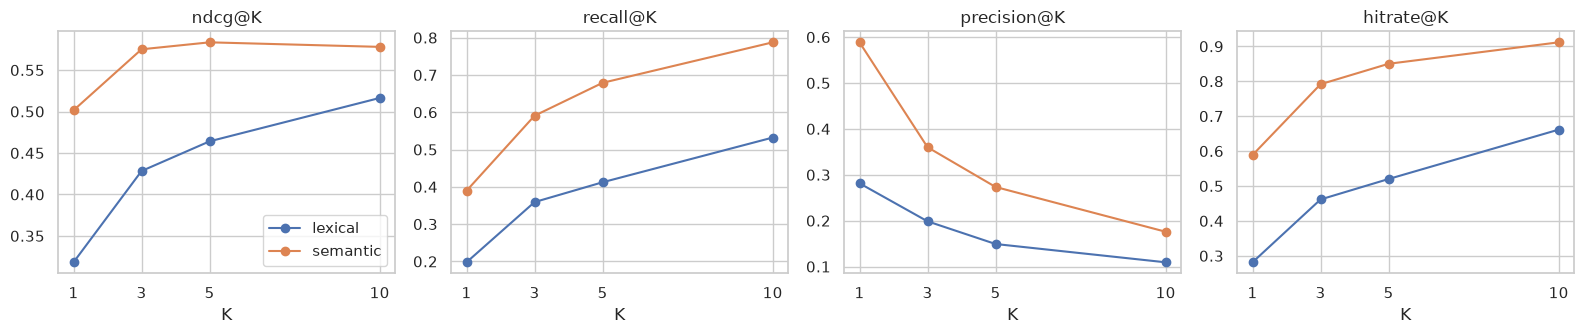

In [31]:
fig, axes = plt.subplots(1, 4, figsize=(16, 3.5))
for ax, metric in zip(axes, ["ndcg", "recall", "precision", "hitrate"]):
    for name in summary.index:
        ax.plot(
            K_VALUES,
            [summary.loc[name, f"{metric}_at_{k}"] for k in K_VALUES],
            marker="o",
            label=name,
        )
    ax.set(title=f"{metric}@K", xlabel="K", xticks=K_VALUES)
axes[0].legend()
plt.tight_layout()
plt.show()

**Вывод: зависимость от K**

- Семантический поиск лучше лексического при всех K по всем метрикам, кривые нигде не пересекаются.
- У семантики NDCG@K выходит на плато уже к K = 3–5 (0.575 → 0.578): основная ценность выдачи сосредоточена в первых позициях. У лексики NDCG@K растёт до K = 10, потому что хвост топа заполняется размеченными товарами с оценкой 1 (подробнее о смещении пула — в базовом сравнении ниже).
- Precision@K падает с ростом K у обоих подходов: на запрос приходится мало релевантных товаров, и это ограничение разметки, а не алгоритма.

In [32]:
search_lexical_full = build_lexical(catalog)
search_semantic_full = build_semantic(catalog, emb)
sample_ids = pd.Series(list(golden_train)).sample(100, random_state=SEED)
golden_sample = {qid: golden_train[qid] for qid in sample_ids}

display(
    pd.DataFrame(
        {
            (name, scope): evaluate(search, golden_sample)[KEY_METRICS].mean()
            for name, scope, search in [
                ("lexical", "пул", search_lexical),
                ("lexical", "весь каталог", search_lexical_full),
                ("semantic", "пул", search_semantic),
                ("semantic", "весь каталог", search_semantic_full),
            ]
        }
    ).T.round(3)
)

text, rel_map = golden_sample[sample_ids.iat[0]]
print(f"Запрос: {text}")
search_semantic_full(text, 10).assign(
    rel=lambda d: d["imt_id"].map(rel_map),
    in_labels=lambda d: d["imt_id"].isin(rel_map),
)

ndcg_at_10  recall_at_10    mrr  precision_at_5  \
lexical  пул                0.524         0.561  0.378           0.154   
         весь каталог       0.073         0.148  0.061           0.030   
semantic пул                0.560         0.738  0.682           0.250   
         весь каталог       0.207         0.393  0.282           0.088   

                       hitrate_at_10  
lexical  пул                    0.72  
         весь каталог           0.21  
semantic пул                    0.87  
         весь каталог           0.56

Запрос: топы cop copine


,imt_id,imt_name,subj_name,score,rel,in_labels
0,10022243,Топ,Топы,0.870343,NaN,False
1,10022253,Топ,Топы,0.867683,NaN,False
2,10022264,Топ,Топы,0.867210,NaN,False
3,10022252,Топ,Топы,0.867084,3.0,True
4,1009580,Топ,Топы,0.865680,NaN,False
5,1009582,Топ,Топы,0.865680,NaN,False
6,1009638,Топ,Топы,0.865428,NaN,False
7,1003736,Топ,Топы,0.865428,NaN,False
8,10067786,Топы,Топы,0.864545,NaN,False
9,10022566,Топ женский,Топы,0.864230,1.0,True


**Вывод: поиск по всему каталогу против каталога оценки (100 запросов train)**

| Подход | Каталог | NDCG@10 | Recall@10 | MRR | HitRate@10 |
|---|---|---|---|---|---|
| lexical | пул (4 256) | 0.524 | 0.561 | 0.378 | 0.72 |
| lexical | весь (48 376) | 0.073 | 0.148 | 0.061 | 0.21 |
| semantic | пул (4 256) | 0.560 | 0.738 | 0.682 | 0.87 |
| semantic | весь (48 376) | 0.207 | 0.393 | 0.282 | 0.56 |

- При поиске по всему каталогу метрики падают в 2.5–7 раз. Причина не в качестве поиска, а в разметке: оценено около 9% каталога, и топ заполняется неразмеченными товарами, которые автоматически считаются нерелевантными. Например, по запросу «топы cop copine» 8 из 10 результатов — неразмеченные «Топ» из категории «Топы». **Поэтому итоговая оценка ведётся на каталоге, ограниченном пулом асессоров.**
- Порядок подходов при этом сохраняется, а семантика деградирует заметно меньше: HitRate@10 0.56 против 0.21. Её преимущество не артефакт маленького каталога.
- В каталоге есть карточки с одинаковым текстом (одинаковое название, категория, бренд и цвет). Они получают равный скор и занимают несколько позиций топа. Дедупликация по тексту — кандидат на улучшение.

In [33]:
def label_coverage(search, golden: dict, k: int = 10) -> pd.Series:
    """Доли товаров в топ-k по оценкам разметки (NaN - не размечен)."""
    rels = [
        rel_map.get(i)
        for text, rel_map in golden.values()
        for i in search(text, k)["imt_id"]
    ]
    return (
        pd.Series(rels)
        .value_counts(normalize=True, dropna=False)
        .sort_index()
        .rename(lambda x: "не размечен" if pd.isna(x) else f"rel={int(x)}")
    )


pd.DataFrame(
    {
        name: label_coverage(search, golden_train)
        for name, search in [("lexical", search_lexical), ("semantic", search_semantic)]
    }
).round(3)

,lexical,semantic
rel=1,0.589,0.246
rel=2,0.058,0.096
rel=3,0.051,0.080
не размечен,0.302,0.578


**Вывод: базовое сравнение (train, 700 запросов, каталог оценки 4 256, порог relevance ≥ 2)**

| Метрика | Лексический (TF-IDF) | Семантический (e5-small) |
|---|---|---|
| NDCG@10 | 0.516 | **0.578** |
| Recall@10 | 0.532 | **0.787** |
| MRR | 0.391 | **0.700** |
| Precision@5 | 0.149 | **0.273** |
| HitRate@10 | 0.661 | **0.911** |

- **Семантический поиск лучше по всем метрикам и всем K.** Сильнее всего он выигрывает на первых позициях: MRR 0.700 против 0.391, HitRate@1 0.589 против 0.281. В 59% запросов первый результат релевантен, у TF-IDF — в 28%. В топ-10 семантика находит хотя бы один релевантный товар для 91% запросов против 66% у лексики.
- **Precision@K низкий у обоих подходов, и это ожидаемо:** у медианного запроса один релевантный товар, так что Precision@5 ограничен сверху значением около 0.2–0.3. Поэтому решение принимаем по NDCG@10, Recall@10 и MRR.
- **Разрыв по NDCG@10 (+12%) заметно меньше, чем по Recall@10 (+48%) и MRR (+79%).** Причина в смещении пулированной разметки. В топ-10 лексического поиска 59% товаров размечены оценкой 1 и только 30% не размечены. У семантического 25% товаров с оценкой 1 и 58% неразмеченных. Кандидаты для разметки, по-видимому, отбирались лексически похожим способом, и TF-IDF возвращает их чаще. Оценка 1 по порогу означает «нерелевантен», но в NDCG даёт gain = 1, поэтому NDCG частично вознаграждает лексику за попадание в пул.
- **Метрики семантического поиска, вероятно, занижены:** более половины его выдачи не размечены и по соглашению считаются нерелевантными, хотя часть из них может подходить пользователю. Для честного сравнения нужна доразметка топа семантического поиска. Это рекомендация на следующие шаги.

### Итоги первой итерации

**Что работает:**
- Семантический поиск (e5-small) превосходит TF-IDF по всем метрикам: NDCG@10 0.578 против 0.516, Recall@10 0.787 против 0.532, MRR 0.700 против 0.391. Он удерживает тип товара и понимает синонимы и разные формы слов («кожаные» ↔ «натуральная кожа»).
- Лексический поиск силён на точных редких словах, таких как «зуавы» и бренды латиницей.

**Что работает плохо:**
- Семантика слабо учитывает бренд (~36% запросов его содержат) и теряет смысл на коротких латинских токенах («mego as»).
- Лексика не понимает морфологию и синонимы и на брендовых запросах выдаёт товары бренда из чужих категорий.
- Карточки-близнецы с одинаковым текстом занимают несколько мест топа.
- Оценка ограничена пулированной разметкой: неразмеченные товары считаются нерелевантными, и это занижает метрики семантики (58% её топ-10 не размечено).

**Гипотезы для недели 3:**
1. **Гибридный поиск (RRF или взвешенная сумма скоров)** улучшит NDCG@10 и MRR: ошибки двух подходов разного характера (бренды и редкие термины против типа товара и синонимов).
2. **Лемматизация и стоп-слова для TF-IDF** повысят Recall@10 лексического поиска, который сейчас не сопоставляет формы слов («кожаные» / «кожа»). Это также усилит гибрид.
3. **Более сильная русскоязычная модель** (`deepvk/USER-base`) или **дообучение e5 на парах «запрос → товар» из train** улучшат ранжирование внутри категории и работу с брендами.
4. **Шаблон `product_text` с явными метками атрибутов** («бренд: …, цвет: …») поможет модели отличать бренд от описания товара.

---

## Неделя 3 — эксперименты, дообучение и MLflow

**Цель:** проверить гипотезы о том, как можно улучшить систему поиска, зафиксировать эксперименты, дать рекомендации бизнесу.

**Главное правило:** «один эксперимент — одна гипотеза — одно изменение». Если поменять сразу модель, шаблон текста и параметры векторизации, прирост будет невозможно объяснить и повторить.

### 1. Эксперименты по улучшению

Проведите минимум три эксперимента. Оформляйте каждый по схеме:

- **Гипотеза** — ваше предположение и его обоснование. Причины «хочу попробовать другую модель» недостаточно, нужны объяснения такого типа: «Модель с большим окном улучшит поиск товаров с длинными описаниями, потому что в EDA я видел, что X% описаний обрезаются по лимиту токенов».
- **Что меняется** — ровно один компонент относительно baseline.
- **Результат** — метрики на тех же данных, с тем же порогом и теми же K.
- **Вывод** — принимаем или отклоняем гипотезу. Что это говорит о данных?

Придумывайте гипотезы, опираясь на ошибки, которые обнаружили на неделе 2. Если выбранная модель путает смежные категории, попробуйте проверить, решит ли проблему добавление данных из `subj_name` в общий текст карточки. Другой пример: если лексический поиск обходит семантический на точных названиях, а семантический выигрывает у лексического, когда дело доходит до неточных формулировок, — это повод попробовать реализовать гибридный поиск.

Направления для разработки гипотез:

- изменить шаблон `product_text`;
- попробовать другую модель эмбеддингов;
- дообучить модели;
- реализовать гибридный поиск с помощью взвешенной суммы скоров или реранкинга семантикой поверх лексического отбора;
- ввести лемматизацию и стоп-слова для TF-IDF;
- изменить параметры векторизации.

In [34]:
# Эксперимент 1
# Гипотеза:
# Что меняем:


# Ваш код

...

Ellipsis

### 2. Финальный тест

Выборка `test` нужна для финальной проверки модели, когда конфигурация окончательно выбрана по результатам валидации. Каждый повторный прогон с подстройкой превращает `test` в ещё одну валидацию и обесценивает финальные показатели.

In [35]:
RUN_FINAL_TEST_EVAL = False  # Переведите в True, когда конфигурация финальная

# Ваш код


### 3. Трекинг экспериментов в MLflow

Каждая конфигурация — отдельный run с осмысленным именем (`semantic_bge_m3`, а не `run_7`).

Что логировать:
- Все параметры, известные до запуска, — метод, модель, шаблон текста, порог, размер каталога, сид.
- Метрики — все посчитанные значения.
- Артефакты — таблица метрик по запросам, сводная таблица, графики, копия данных, на которых проводилась проверка.

In [36]:
# Ваш код: подключение к MLflow из .env и логирование прогонов

### 4. Финальные выводы

**4.1. Сводная таблица.** Все подходы на одних данных, с одинаковыми порогом и K. Укажите лучшую конфигурацию и метрики, по которым был сделан вывод.

**4.2. Качественный анализ.** Числа показывают не всю картину. Возьмите запросы, где лучший подход всё ещё ошибается, и опишите характер ошибок.

**4.3. Ограничения оценки.** Перечислите ограничения модели и данных, на которых проводились эксперименты. Например:

- разметка синтетическая и пулированная;
- каталог оценки меньше реального;
- запросы сгенерированы, а не собраны от пользователей.

Этот раздел не ослабляет работу, а усиливает её: специалист, понимающий границы своего решения, вызывает больше доверия.

**4.4. Рекомендация бизнесу.** Скажите заказчику, внедрять ли ему векторный поиск или нет, в каком виде его лучше реализовывать, в каких сценариях он будет помогать, а где может ошибаться.

**4.5. Дальнейшие шаги.** Перечислите возможные действия, которые могли бы улучшить результат:

- использовать реальные логи запросов вместо синтетических;
- перейти на ANN-индекс при росте каталога;
- применить фильтры по атрибутам поверх векторного поиска.

Все возможные шаги обоснуйте.


*Ваши выводы:*
